<a href="https://colab.research.google.com/github/panindarkwah/Neural_NetworkLab---3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


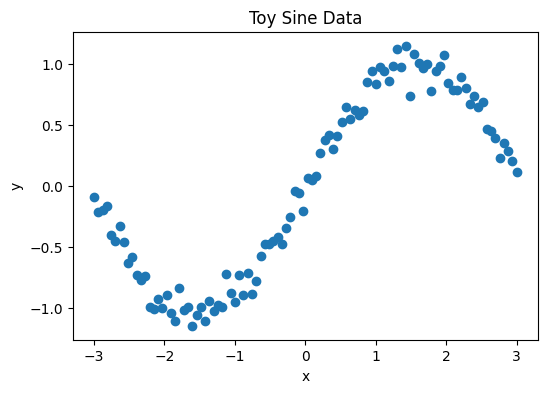

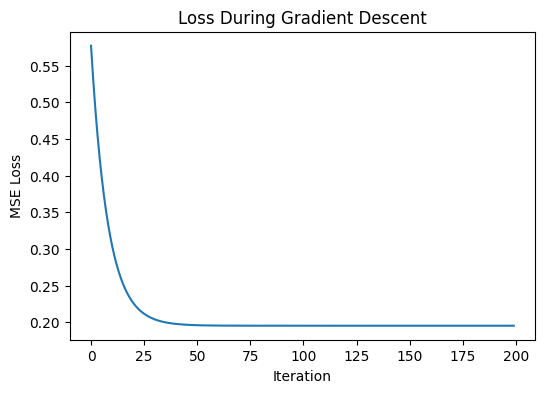

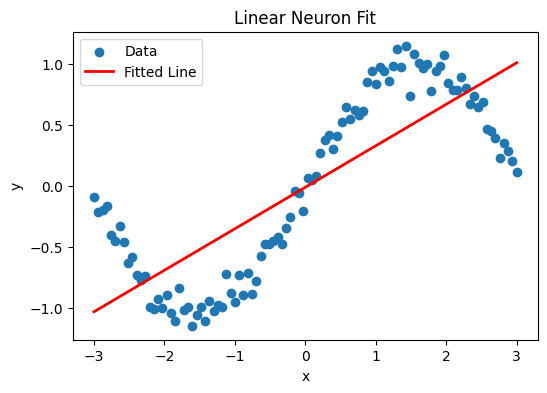

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)
#   Plot it.
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Sine Data")
plt.show()


# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

lr = 0.01
losses = []

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
for i in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    w -= lr * dw
    b -= lr * db

# TODO: Plot (a) the loss curve over the 200 steps, and
# Plot the loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss During Gradient Descent")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.show()

# Plot the fitted line
y_hat = w * x + b

#(b) the data with the fitted line on top.
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", linewidth=2, label="Fitted Line")
plt.title("Linear Neuron Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

1.
### Derivation of $\frac{\partial \text{Loss}}{\partial w}$

The prediction is:

$$
\hat{y} = wx + b
$$

The Mean Squared Error loss is:

$$
L = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2
$$

Differentiate with respect to $w$:

$$
\frac{\partial L}{\partial w}
=
\frac{1}{n}
\sum_{i=1}^{n}
2(\hat{y}_i-y_i)x_i
$$

Therefore,

$$
\frac{\partial L}{\partial w}
=
\text{mean}\left(2(\hat{y}-y)x\right)
$$

This matches the code:

```python
dw = np.mean(2 * (y_hat - y) * x)
```

PART 1.1

2. The fit stops improving even though the fit is bad because, the single neuron only computes a linear function, hower the target data is generated from y = sin(x) + noise, which is a non-linear function. The gradient descent can only adjust the values of w and b; it cannot change the model from a straight line to a curve. After multiple iterations, it just finds the line that best fits, so the loss stops decreasing. To model the target, we need a model capable of representing nonlinear relationships, such as a neural network with one or more hidden layers and nonlinear activation functions
The poor fit is caused by underfitting because the model is too simple to represent the nonlinear pattern in the data.

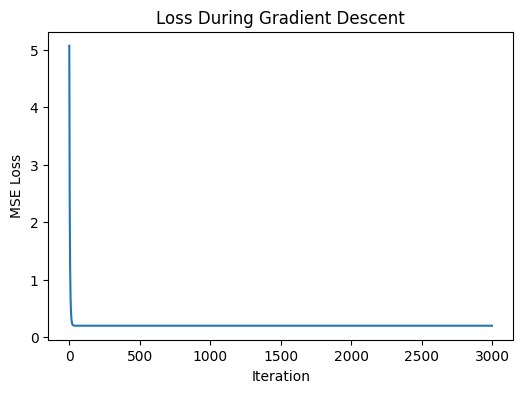

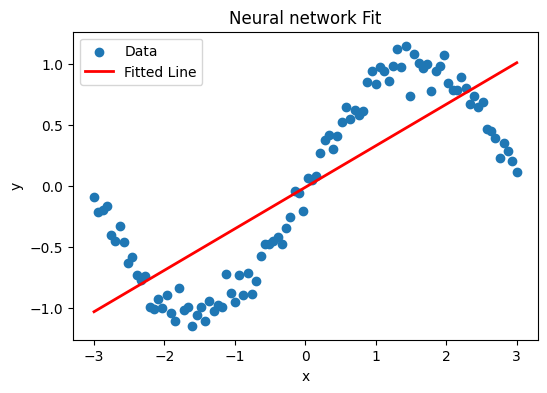

In [3]:
# TODO: Initialise parameters
w1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5

w2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

x = x.reshape(-1,1)
y = y.reshape(-1,1)



# TODO: Implement ONE gradient-descent step by hand, then loop it for ~3000 steps:



# TODO: Forward pass (keep the intermediate values — you need them for backprop):
z1 = x @ w1 + b1        # pre-activation, shape (100, 8)
h  = np.tanh(z1)        # activation
y_hat = h @ w2 + b2     # output, shape (100, 1)
loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat
db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ w2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
dW1 = x.T @ dz1
db1 = dz1.sum(axis=0)


# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
w1 -= lr * dW1
b1 -= lr * db1
w2 -= lr * dW2
b2 -= lr * db2
#   record the loss.
losses = []

for i in range(3000):

  z1 = x @ w1 + b1
  #h = np.tanh(z1)
  h = z1
  y_hat = h @ w2 + b2

  loss = np.mean((y_hat - y) ** 2)
  losses.append(loss)

  d_yhat = 2 * (y_hat - y) / len(y)

  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)

  dh = d_yhat @ w2.T
  #dz1 = dh * (1 - np.tanh(z1) ** 2)
  dz1 = dh

  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)

  # Update
  w1 -= lr * dW1
  b1 -= lr * db1
  w2 -= lr * dW2
  b2 -= lr * db2

# TODO: Plot the loss curve AND the final fit over the data.
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss During Gradient Descent")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.show()
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", linewidth=2, label="Fitted Line")
plt.title("Neural network Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


PART **1.2**
When the tanh is removed, the line fit becomes a strsight line.

1. With out the activation function, the networ =k becomes z1​=xW1​+b1​ and the output layer becomes y^​=z1​W2​+b2​. Substituting z1 into the second equation becomes
^​=(xW1​+b1​)W2​+b2​
^​=xW1​W2​+b1​W2​+b2​  this can be writeen a ^​=xW+b , they are jus new weights and biases. The equation is still a linear equation after stacking the multiple linear layers. The number of linear layers doesn't determine the model's ability to solve complex patterns, but the activation function is what introduces the non-linearity for the model to solve those complex patterns.

2. The hidden 8 neuron act as feature detectors, each neuron receives the input x, applies a different weight and bais , and produces a different nonlinear transformation. Becuase the activation funtion is non-linear aach neuron creates a different Curve feature of the input. The output feature then combines these 8 learned features to approximate the sine wave.

3. Backpropagation is an algorithm that examines when a neural network makes a prediction, checks how wrong it was, then sends the error backwards through the network to figure out which weights caused the mistake and how they could be adjusted.

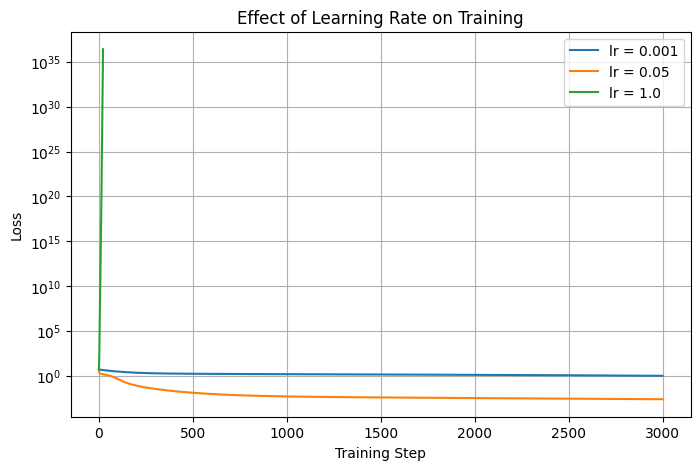

In [5]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000):
  torch.manual_seed(42)

  x = torch.linspace(-2, 2, 100).unsqueeze(1)
  y = x**2

  model = torch.nn.Sequential(
      torch.nn.Linear(1, 8),
      torch.nn.Tanh(),
      torch.nn.Linear(8, 1)
  )

  criterion = torch.nn.MSELoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=lr)

  losses = []

  for step in range(steps):
      y_hat = model(x)
      loss = criterion(y_hat, y)
      losses.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

  return losses

#

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
loss_lr1 = train_toy(0.001)
loss_lr2 = train_toy(0.05)
loss_lr3 = train_toy(1.0)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(8, 5))

plt.plot(loss_lr1, label="lr = 0.001")
plt.plot(loss_lr2, label="lr = 0.05")
plt.plot(loss_lr3, label="lr = 1.0")

plt.yscale("log")        # Log scale on y-axis
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate on Training")
plt.legend()
plt.grid(True)

plt.show()


1. The curve with learning rate 0.001 decreases very slowly. Due to the small distance in steps taken, the model takes a long time in updating the weights.
 The curve showing the leraning raqte of 0.05, is that of a good learning rate. The loss decreases Rapidly during the first few hundred iterations, and it eventually flattens because the model is close to the minimum loss. The traing is is set at an optimal pace that makes it reach the minimum loss quickly.
 The curve of learning rate 1.0 grows to become larger. The curve oscillate and even end up predicting extreme wrong values.
 A too-large learning rate means that a step taken could cause the model to repeatedly miss the minimum value. This process continues repeatedly, causing the loss to oscillate. The jump could be even larger than the computer can not represent accurately. This causes the exploding loss.

In [10]:

from matplotlib.collections import transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import TensorDataset, DataLoader
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
# Loading the dataset
df = pd.read_csv(OBESITY_URL)
df.head()

binary_map = {"yes" : 1, "no" : 0}

df["family_history_with_overweight"] = (df["family_history_with_overweight"].str.lower().map(binary_map))

df["FAVC"] = (df["FAVC"].str.lower().map(binary_map))

df["SMOKE"] = (df["SMOKE"].str.lower().map(binary_map))

df["SCC"] = (df["SCC"].str.lower().map(binary_map))

# Encode Gender
gender_map = {
    "Female": 0,
    "Male": 1
}

df["Gender"] = df["Gender"].map(gender_map)

# Encode CAEC
caec_map = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}

df["CAEC"] = df["CAEC"].map(caec_map)

# Encode CALC
calc_map = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}

df["CALC"] = df["CALC"].map(calc_map)

# Encode MTRANS
mtrans_map = {
    "Automobile": 0,
    "Motorbike": 1,
    "Bike": 2,
    "Public_Transportation": 3,
    "Walking": 4
}
df["MTRANS"] = df["MTRANS"].map(mtrans_map)

#Encode target
label_encode = LabelEncoder()
df["NObeyesdad"] = label_encode.fit_transform(df["NObeyesdad"])

#Split fetures and transforms
x = df.drop("NObeyesdad", axis = 1)

y = df["NObeyesdad"]

x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.4, random_state=42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5
)

# Standardize features
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

#convert to tensors
x_train = torch.tensor(x_train, dtype=torch.float32)
x_val = torch.tensor(x_val, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_val = torch.tensor(y_val.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

#create TensorDatasets
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

#create DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

CrossEntropyLoss expects integer class labels because it uses each integer as the index of the correct class when computing the loss. It then internally applies Softmax to convert ouput to probabilities and computes the cross-entropy.
The one-hot encoding involves the uses a vector form which contains 7 entries  to represent a feature. This consumes more memory space and requires more work. The CrossEntropyLoss is memory efficient and faster because it can directly Index the correct class without converting from one-hot format. It computes the loss more efficiently than using one-hot-encoded target vectors.

2. Random forest careless about feature scaling because they make decisons Based on comparsons which depends on the order of thevalues , nt their scales. Using scales has little or no effect on the deciosn random forest makes as its hgoing to make the same spilts.
Neural networks care more about feature scaling because it performs lots of mathematical operations, and if one feature is larger, it dominates the learning. This makes the optimiser focus on a feature due to its large weights and not because theerformsy are important. The scaling ensures that each feature are on a similar scale, and they all contribute fairly during training.

3. The shuffle=True randomly changes the order of training samples at the start of every input. This prevents the model From Learning patterns caused by the order of the data ensures every batch contains a more representative mixture of examples, producing more stable gradient updates and better generalisation.